# importing Dataset

In [1]:
# !pip install -q kaggle
# !mkdir -p ~/.kaggle
# !mv kaggle.json ~/.kaggle/
# !chmod +600 ~/.kaggle/kaggle.json

# !kaggle competitions download -c comment-category-prediction-challenge
# !unzip comment-category-prediction-challenge.zip

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
%matplotlib inline

from scipy import sparse
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, cross_val_predict, GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, f1_score, confusion_matrix

import lightgbm as lgb
from lightgbm import LGBMClassifier

In [3]:
pd.set_option('display.max_columns', None)

# Loading Dataset

In [4]:
train_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nFirst few rows:")
train_df.head()

Train shape: (198000, 15)
Test shape: (102000, 14)

First few rows:


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [5]:
# missing values percentage
train_df.isna().mean() * 100

created_date     0.000000
post_id          0.000000
emoticon_1       0.000000
emoticon_2       0.000000
emoticon_3       0.000000
upvote           0.000000
downvote         0.000000
if_1             0.000000
if_2             0.000000
race            73.445960
religion        73.445960
gender          73.445960
disability       0.000000
comment          0.000505
label            0.000000
dtype: float64

Observations
- 73%+ values are null in religion, race, and gender
- one null in comment
- Now, thinking of the problem statement, i feel this is `Missing At Random` --> people chose NOT to reveal their identity for privacy concern.

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


Observations
- All types are almost correct, Just date is to be changed in preprocess

In [7]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
post_id,198000.0,68.447429,27.948390,20.0,39.0,72.0,72.0,129.0
emoticon_1,198000.0,0.279768,1.023234,0.0,0.0,0.0,0.0,47.0
emoticon_2,198000.0,0.048338,0.258477,0.0,0.0,0.0,0.0,11.0
emoticon_3,198000.0,0.121071,0.481013,0.0,0.0,0.0,0.0,17.0
upvote,198000.0,2.607975,5.054763,0.0,0.0,1.0,3.0,201.0
downvote,198000.0,0.666394,2.044335,0.0,0.0,0.0,1.0,107.0
if_1,198000.0,1.906152,25.635752,0.0,0.0,0.0,4.0,1860.0
if_2,198000.0,7.956212,14.839464,3.0,4.0,6.0,10.0,1833.0
label,198000.0,0.793965,0.979808,0.0,0.0,0.0,2.0,3.0


Observations
- Outliers in emoticon_1, emoticon_2, emoticon_3, upvote, downvote, if columns
- Mostly all Columns are right (positive) skewed --> mean > median > mode (if outliers are ignored)
- few very large values in upvote, downvote, and if_1, if_2
- Scaling needed if using linear models, (to get it squeezed in range without altering the distribution).

# EDA

### HeatMap

<Axes: >

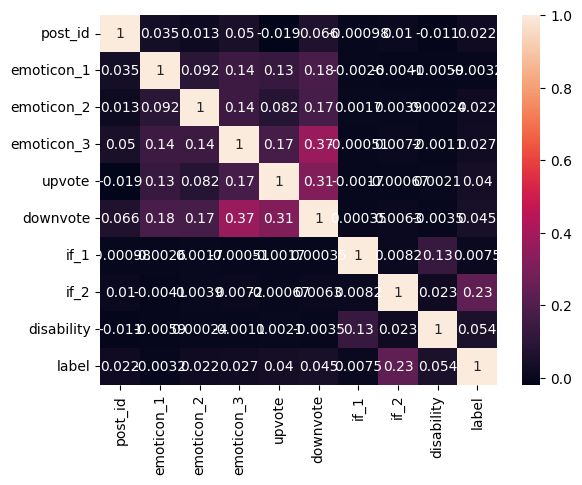

In [8]:
corr = train_df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

Observations

- if_2 is highly correlated with our target.
- downvote and emoticon_3 are inter-correlated
- downvote and upvote are inter-correlated


### Lable Distribution (CLass Imbalance Overview)

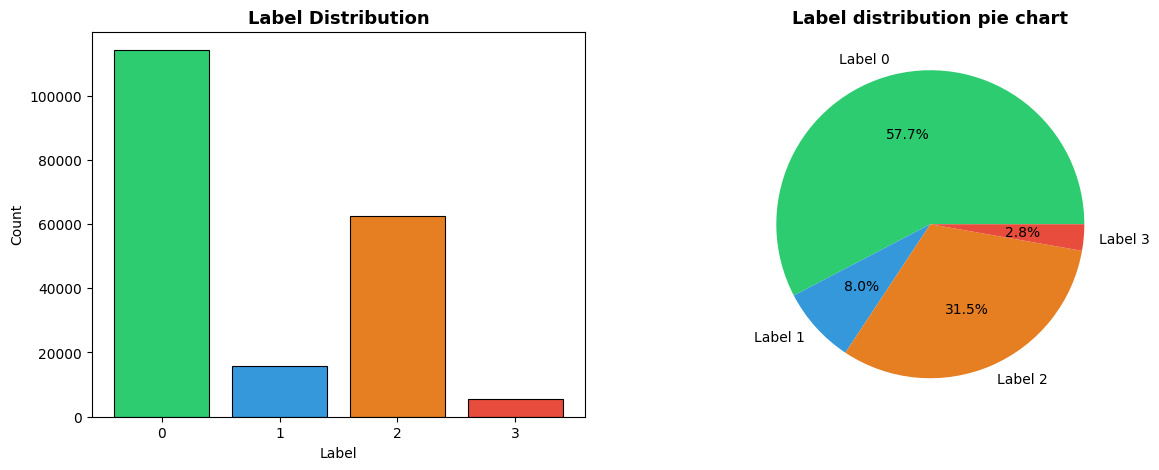

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
label_counts = train_df['label'].value_counts().sort_index()
colors=['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', linewidth=0.8)

axes[0].set_title('Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Label'); axes[0].set_ylabel('Count')
axes[0].set_xticks([0,1,2,3])


# pie chart
axes[1].pie(label_counts.values, labels=[f"Label {i}" for i in label_counts.index], autopct="%1.1f%%", colors=colors)
axes[1].set_title("Label distribution pie chart", fontsize=13, fontweight="bold")

plt.show()

Observation
- Dataset is highly imbalanced --> Accuracy wont be a good metric to judge this PS
- 1 and 3 are minority class --> would need good preprocessing for our model to guess minority classes

### Text Length Distribution wrt Label

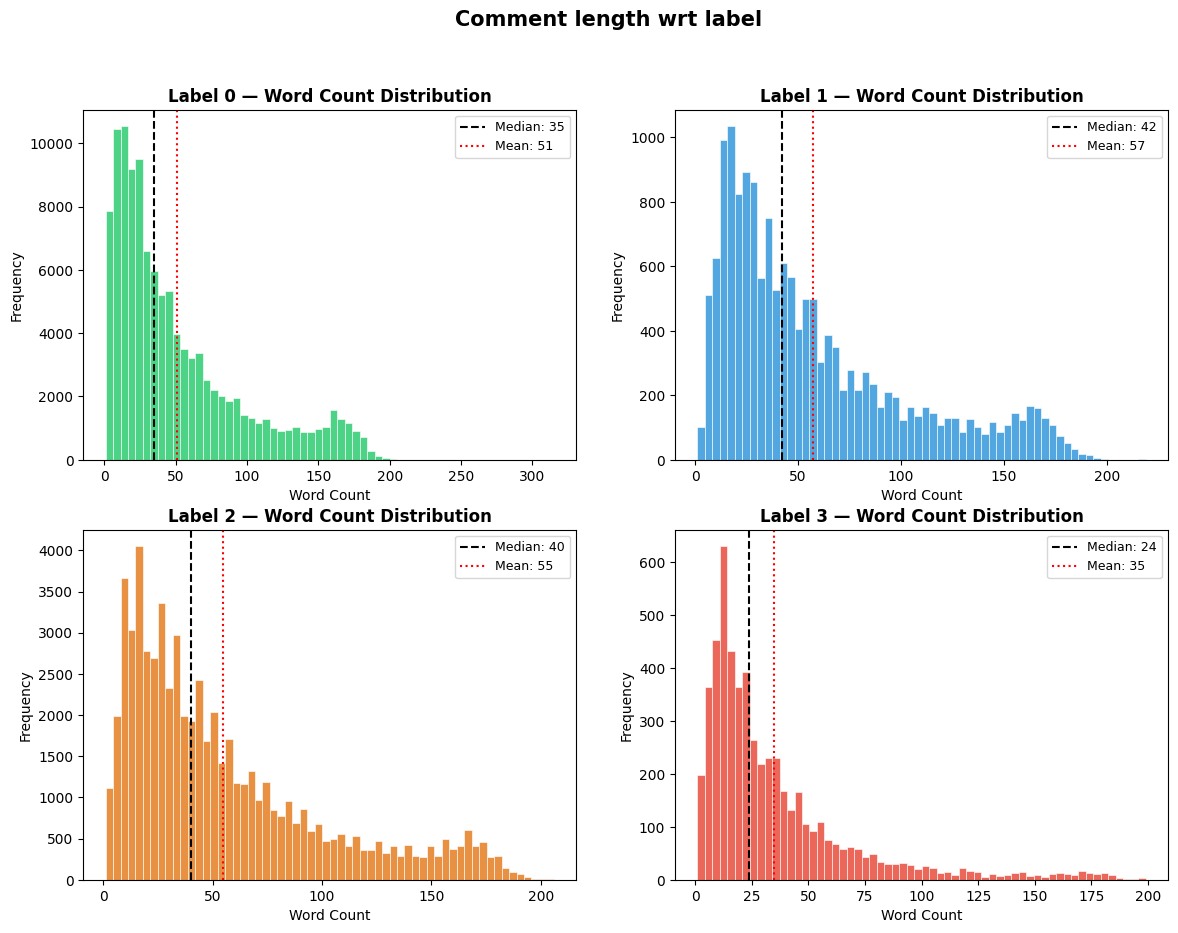

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for label in sorted(train_df['label'].unique()):
    subset = train_df[train_df['label'] == label]
    word_counts = subset['comment'].apply(lambda x: len(str(x).split()))

    axes[label].hist(word_counts, bins=60, color=colors[label], edgecolor='white', linewidth=0.5, alpha=0.85)

    # median line
    axes[label].axvline(word_counts.median(), color='black', linestyle='--', linewidth=1.5, label=f'Median: {word_counts.median():.0f}')

    # mean line
    axes[label].axvline(word_counts.mean(), color='red', linestyle=':', linewidth=1.5, label=f'Mean: {word_counts.mean():.0f}')

    # aesthetics
    axes[label].set_title(f'Label {label} — Word Count Distribution', fontsize=12, fontweight='bold')
    axes[label].set_xlabel('Word Count'); axes[label].set_ylabel('Frequency')
    axes[label].legend(fontsize=9)

plt.suptitle("Comment length wrt label", fontsize=15, fontweight="bold")
plt.show()
    

Observations
- Since the mean is in the right to the median, the data is right (positive) skewed (also visible from the bin)
- So few extremes (outliers) shifts the mean to right.
- Relationship of right skewed (Mean > Median > Mode) {also seen from the graph}

### if_1 and if_2 distribution wrt label

In [11]:
train_df.groupby(['label', 'if_2']).size().unstack(fill_value=0)

if_2,3,4,5,6,7,8,9,10,11,12,13,26,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,79,80,81,82,84,100,110,123,1071,1079,1114,1142,1153,1171,1373,1527,1607,1633,1660,1676,1694,1833
label,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,3,89818,5293,12774,334,42,138,5464,22,1,0,0,2,3,3,9,3,6,1,8,6,10,8,9,11,10,4,8,8,7,5,6,14,15,5,10,8,5,6,6,5,15,4,6,2,11,1,5,1,5,0,5,5,1,0,8,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1
1,0,66,46,92,1,2,1,15138,65,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,1,3,3,3,3,10,6,16,4,10,4,34,20,28,4,9,14,85,20,9,1,42,22,47,4,1,91,6,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,1772,815,1623,31,0,17,55067,210,13,5,1,1,2,0,1,1,3,6,2,2,3,6,5,4,7,16,13,17,19,28,28,22,45,50,59,49,68,44,109,90,145,59,112,60,224,136,166,27,132,82,313,73,60,6,173,91,148,8,0,160,9,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,70,34,69,0,0,1,5024,15,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,1,3,3,0,2,1,6,6,10,8,8,4,12,6,9,2,10,8,50,8,6,0,15,13,18,1,0,35,3,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


/tmp/ipykernel_17/2793142903.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='label', y='if_2', palette=colors, ax=axes[0][0], width=0.5)
/tmp/ipykernel_17/2793142903.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='label', y='if_1', palette=colors, ax=axes[0][1], width=0.5)


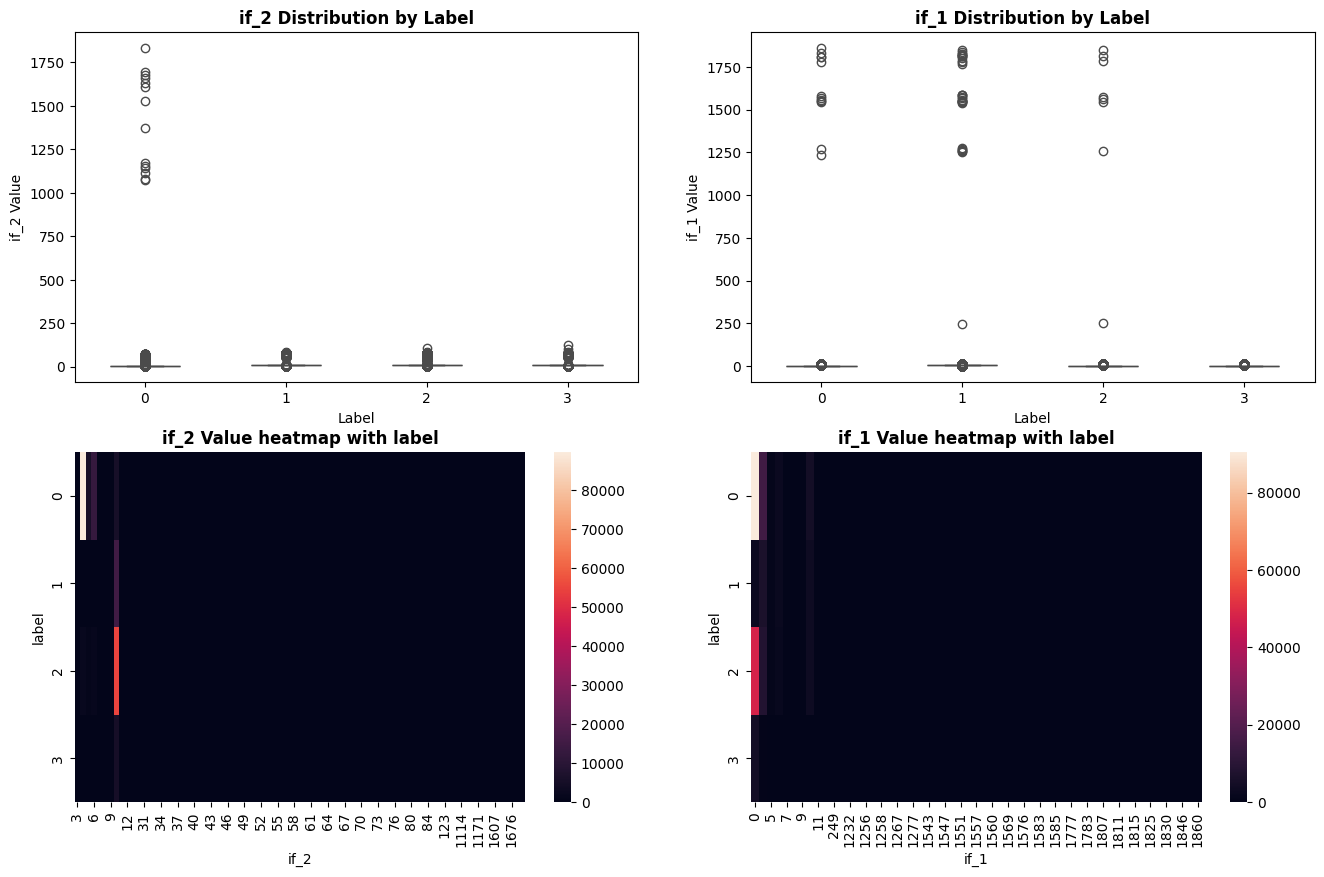

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# top left
sns.boxplot(data=train_df, x='label', y='if_2', palette=colors, ax=axes[0][0], width=0.5)
axes[0][0].set_title('if_2 Distribution by Label', fontsize=12, fontweight='bold')
axes[0][0].set_xlabel('Label'); axes[0][0].set_ylabel('if_2 Value')

# top right
sns.boxplot(data=train_df, x='label', y='if_1', palette=colors, ax=axes[0][1], width=0.5)
axes[0][1].set_title('if_1 Distribution by Label', fontsize=12, fontweight='bold')
axes[0][1].set_xlabel('Label'); axes[0][1].set_ylabel('if_1 Value')

# bottom left
if2_label = train_df.groupby(['label', 'if_2']).size().unstack(fill_value=0)
sns.heatmap(if2_label, ax=axes[1][0], annot=True if if2_label.shape[1] < 20 else False)
axes[1][0].set_title("if_2 Value heatmap with label", fontsize=12, fontweight="bold")

# bottom right
if1_label = train_df.groupby(['label', 'if_1']).size().unstack(fill_value=0)
sns.heatmap(if1_label, ax=axes[1][1], annot=True if if1_label.shape[1] < 20 else False)
axes[1][1].set_title("if_1 Value heatmap with label", fontsize=12, fontweight="bold")

plt.show()

Observations
- Too many large values and outliers present
- for class 0 and 2 if_1 and if_2 are correlated
- value 10 and 4 in if_2 are in most frequency
- value 0 in if_1 is in most frequency

### Word Cloud

Text(0.5, 1.01, 'Word Clouds by Label')

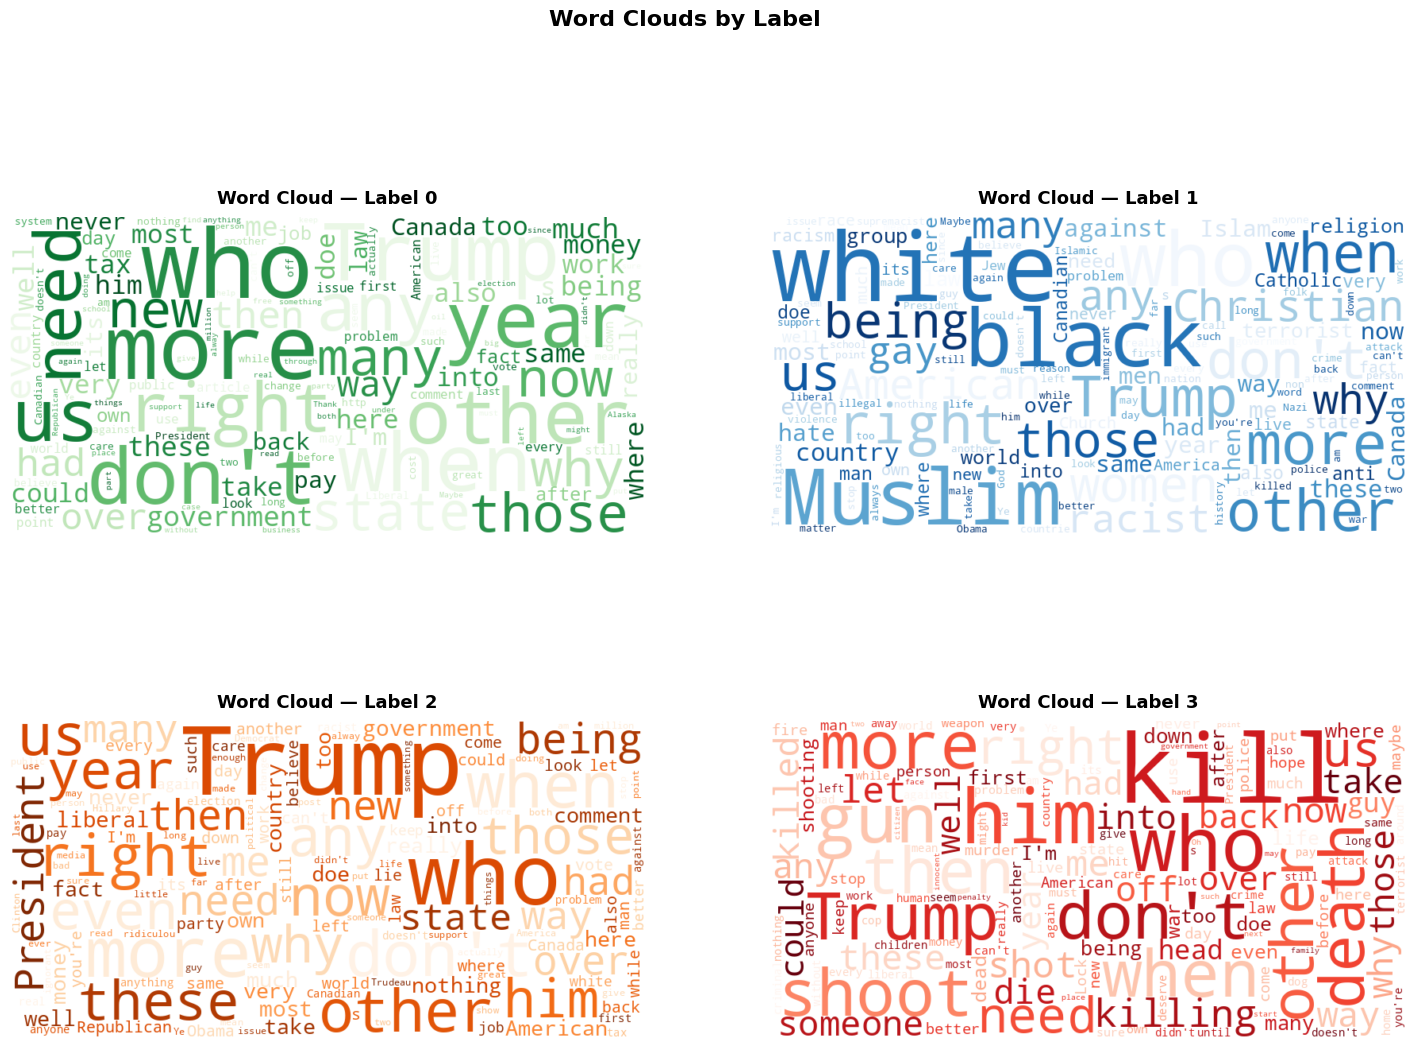

In [13]:
STOPWORDS_WC = set(['the','a','an','and','or','but','in','on','at','to','for',
                    'of','with','is','it','this','that','i','you','he','she',
                    'we','they','be','are','was','were','have','has','do','did',
                    'not','no','so','if','as','by','from','up','about','out',
                    'my','your','will','just','can','get','one','like','all',
                    'would','there','what','know','think','people','time','make',
                    'say','said','going','got','go','see','want','good','thing',
                    'our', 'because', 'their', 'how', 'than', 'been', 'only', 'U', 'some',
                    'which', 'should', 'them', 'his', 'her'
                   ])

label_colors = {0: 'Greens', 1: 'Blues', 2: 'Oranges', 3: 'Reds'}
label_names  = {0: 'Label 0', 1: 'Label 1', 2: 'Label 2', 3: 'Label 3'}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for label in sorted(train_df['label'].unique()):
    text = ' '.join(train_df[train_df['label'] == label]['comment'].astype(str))

    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=label_colors[label],
        stopwords=STOPWORDS_WC,
        max_words=150,
        collocations=False,
        min_font_size=8,
        max_font_size=120,
        random_state=42
    ).generate(text)

    axes[label].imshow(wc, interpolation='bilinear')
    axes[label].axis('off')
    axes[label].set_title(f'Word Cloud — {label_names[label]}',
                          fontsize=13, fontweight='bold', pad=10)

plt.suptitle('Word Clouds by Label', fontsize=16, fontweight='bold', y=1.01)

Observations
- Label 3 is almost toxic and threaths
- Label 1 is mostly racism
- Label 0 and 2 are political

# Preprocess

In [14]:
# drop 1 row with empty comment
train_df = train_df.dropna(subset=['comment']).reset_index(drop=True)

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
  # Basic length metrics
  df['word_count'] = df['comment'].apply(lambda x: len(str(x).split()))
  df['char_count'] = df['comment'].apply(lambda x: len(str(x)))

  # word/char count right skewed --> log transformation
  df['char_count_log'] = np.log1p(df['char_count'])
  
  # Toxicity / Emotion indicators
  df['upper_ratio'] = df['comment'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1))
  df['exclamation_count'] = df['comment'].apply(lambda x: str(x).count('!'))
  df['question_count'] = df['comment'].apply(lambda x: str(x).count('?'))
  df['ellipse_count'] = df['comment'].apply(lambda x: str(x).count('...'))
  df['word_zscore'] = (df['word_count'] - df['word_count'].mean()) / (df['word_count'].std() + 1e-8)
  

  # Date feature breakdown
  df['created_date'] = pd.to_datetime(df['created_date'])
  df['hour'] = df['created_date'].dt.hour
  df['day_of_week'] = df['created_date'].dt.day_of_week

  # interactive features
  df['total_votes'] = df['upvote'] + df['downvote']
  df['vote_ratio'] = df['upvote'] / (df['downvote'] + 1)
  df['net_sentiment'] = df['upvote'] - df['downvote']

  # interactive if_* breakdown
  df['if_product'] = df['if_1'] * df['if_2']
  df['if_ratio'] = df['if_1'] / (df['if_2'] + 1)
  df['if_diff'] = df['if_1'] - df['if_2']
  df['if2_is_10'] = (df['if_2'] == 10).astype(int)
  df['if2_is_4'] = (df['if_2'] == 4).astype(int)
  df['if_max'] = df[['if_1', 'if_2']].max(axis=1)
  df['if_total'] = df['if_1'] + df['if_2']
  df['if1_nz_if2_10'] = ((df['if_1'] != 0) & (df['if_2'] == 10)).astype(int)
  df['if2_4_if1_0'] = ((df['if_2'] == 4) & (df['if_1'] == 0)).astype(int)
  df['if_both'] = ((df['if_1'] > 0) & (df['if_2'] > 0)).astype(int)

  # word features
  IDENTITY_WORDS = ['muslim', 'black', 'white', 'christian', 'jewish', 'hindu',
                  'gay', 'transgender', 'women', 'racist', 'latino', 'religion', 'catholic']
  POLITICAL_WORDS = ['government', 'trump', 'president', 'republican', 'tax', 'state', 'america',
                     'american']
  THREAT_WORDS = ['kill', 'shot', 'shoot', 'dead', 'die', 'gun', 'death', 
                'murder', 'hurt', 'attack', 'bomb', 'threat', 'killing', 'killed', 'weapon',
                 'illegal', 'fire', 'lock', 'war', 'penalty'
                 ]

  df['identity_word_count'] = df['comment'].apply(
    lambda x: sum(w in str(x).lower() for w in IDENTITY_WORDS))
  df['has_identity_word'] = (df['identity_word_count'] > 0).astype(int)
  df['threat_word_count'] = df['comment'].apply(
    lambda x: sum(w in str(x).lower() for w in THREAT_WORDS))
  df['threat_word_density'] = df['threat_word_count'] / (df['word_count'] + 1)
  df['has_threat_word'] = (df['threat_word_count'] > 0).astype(int)
  df['political_word_count'] = df['comment'].apply(
      lambda x: sum(w in str(x).lower() for w in POLITICAL_WORDS))
  df['has_political_word'] = (df['political_word_count'] > 0).astype(int)


  # text cleaning
  def clean_text(text):
      text = str(text).lower()
      # Remove URLs
      text = re.sub(r'http\S+|www\S+|https\S+', '', text)
      # Remove numbers
      text = re.sub(r'\d+', '', text)
      # Remove extra whitespace
      text = re.sub(r'\s+', ' ', text).strip()
      return text

  df['clean_text'] = df['comment'].apply(clean_text)

  # Mapping
  df['disability'] = df['disability'].map({
      True: 1,
      False: 0
  })

  # null in race, religion, gender --> placeholder 'unknown'
  for col in ['race', 'religion', 'gender']:
    df[col] = df[col].fillna('unknown').astype(str).str.lower()

  return df


print("Preprocessing dataframe")
train_df = preprocess(train_df)
test_pd = preprocess(test_df)
print("Preprocessing Done")

Preprocessing dataframe
Preprocessing Done


In [15]:
train_df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,word_count,char_count,char_count_log,upper_ratio,exclamation_count,question_count,ellipse_count,word_zscore,hour,day_of_week,total_votes,vote_ratio,net_sentiment,if_product,if_ratio,if_diff,if2_is_10,if2_is_4,if_max,if_total,if1_nz_if2_10,if2_4_if1_0,if_both,identity_word_count,has_identity_word,threat_word_count,threat_word_density,has_threat_word,political_word_count,has_political_word,clean_text
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,unknown,unknown,unknown,0,She might be a bright spot for a party keou on...,2,20,118,4.779123,0.016807,0,0,0,-0.707824,8,3,1,0.0,-1,0,0.0,-10,1,0,10,10,0,0,0,0,0,0,0.000000,0,0,0,she might be a bright spot for a party keou on...
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,unknown,unknown,unknown,0,"Under Alaska law, a non-tribal member is not b...",0,110,644,6.469250,0.013953,0,0,0,1.258521,21,6,6,6.0,6,0,0.0,-4,0,1,4,4,0,1,0,0,0,0,0.000000,0,1,1,"under alaska law, a non-tribal member is not b..."
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,unknown,unknown,unknown,0,in the future please spare me your strawman dr...,2,133,751,6.622736,0.017287,0,0,0,1.761032,20,2,0,0.0,0,0,0.0,-10,1,0,10,10,0,0,0,0,0,1,0.007463,1,1,1,in the future please spare me your strawman dr...
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,unknown,unknown,unknown,0,"PS: That should have been ""rot"" instead of ""co...",2,15,91,4.521789,0.043478,0,0,0,-0.817066,22,6,5,5.0,5,0,0.0,-10,1,0,10,10,0,0,0,0,0,0,0.000000,0,0,0,"ps: that should have been ""rot"" instead of ""co..."
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,unknown,unknown,unknown,0,"Today, the confederate flag...tomorrow, the na...",2,40,254,5.541264,0.011765,0,0,4,-0.270859,23,5,0,0.0,0,0,0.0,-10,1,0,10,10,0,0,0,0,0,0,0.000000,0,0,0,"today, the confederate flag...tomorrow, the na..."


### Heatmap after preprocessing

<Axes: >

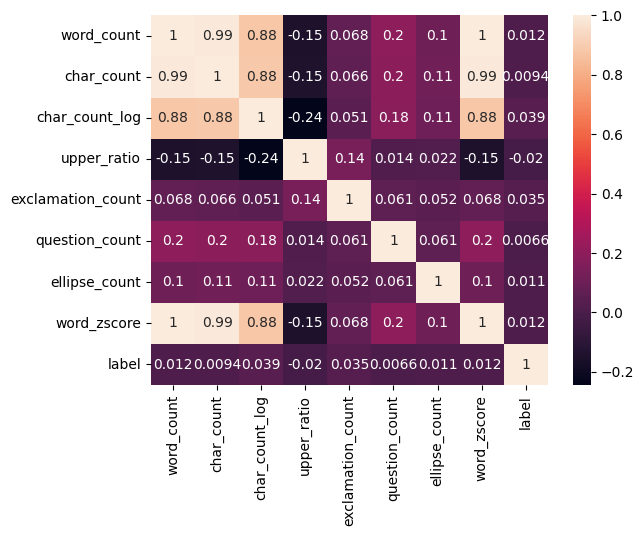

In [16]:
subset = train_df[['word_count', 'char_count', 'char_count_log',
                   'upper_ratio', 'exclamation_count', 'question_count', 'ellipse_count', 
                   'word_zscore', 'label'
                  ]]

corr = subset.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

Observations
Too many redundant inter-correlated features
- word_zscore is exactly same as word_count --> pure duplicate --> drop (no use)
- char_count correlation with word_count is 0.99 --> drop
- Near zero correlations --> post_id, sllipse_count, question_count, hour, day_of_week,

<Axes: >

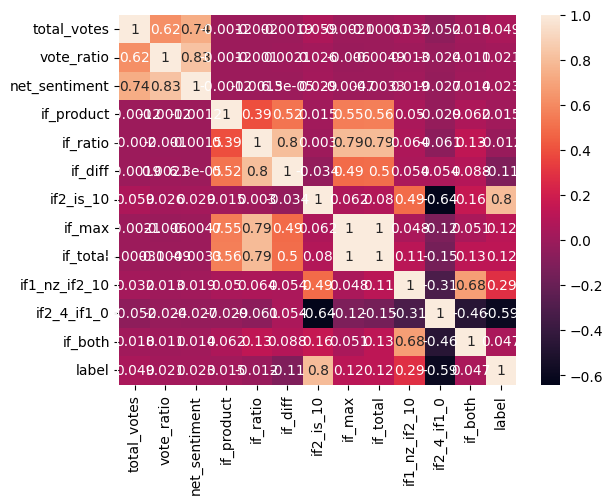

In [17]:
subset = train_df[['total_votes', 'vote_ratio', 'net_sentiment', 'if_product',
                   'if_ratio', 'if_diff', 'if2_is_10', 'if_max', 'if_total',
                   'if1_nz_if2_10',	'if2_4_if1_0',	'if_both', 'label'
                  ]]

corr = subset.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

Observations
- dropping vote_ratio
- if2_is_10 is highly correlated with target
- if1_nz_if2_10 is also highly correlated

<Axes: >

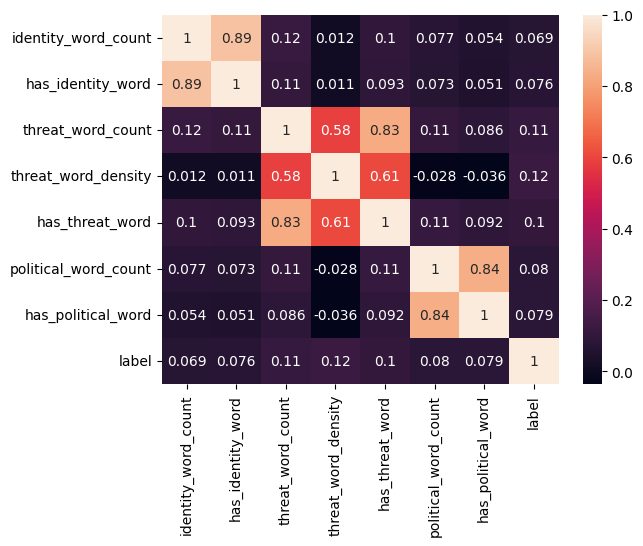

In [18]:
subset = train_df[['identity_word_count', 
                   'has_identity_word', 'threat_word_count', 'threat_word_density', 
                   'has_threat_word', 'political_word_count', 'has_political_word',
                   'label'
                  ]]

corr = subset.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

In [19]:
# unique values in the cateorical columns
print(f"Unique values in race: {train_df['race'].unique()}")
print(f"Value count of values in race: \n{train_df['race'].value_counts()}")

print("-" * 50)

print(f"Unique values in religion: {train_df['religion'].unique()}")
print(f"Value count of values in religion: \n{train_df['religion'].value_counts()}")

print("-" * 50)

print(f"Unique values in gender: {train_df['gender'].unique()}")
print(f"Value count of values in gender: \n{train_df['gender'].value_counts()}")

print("-" * 50)

print(f"Unique values in race: {train_df['race'].unique()}")
print(f"Value count of values in race: \n{train_df['race'].value_counts()}")


Unique values in race: ['unknown' 'none' 'white' 'other' 'asian' 'black' 'latino']
Value count of values in race: 
race
unknown    145423
none        39681
white        5486
black        3869
other        1654
asian        1263
latino        623
Name: count, dtype: int64
--------------------------------------------------
Unique values in religion: ['unknown' 'christian' 'muslim' 'none' 'jewish' 'atheist' 'other' 'hindu'
 'buddhist']
Value count of values in religion: 
religion
unknown      145423
none          38248
christian      7191
muslim         4930
jewish         1244
other           547
atheist         219
buddhist        100
hindu            97
Name: count, dtype: int64
--------------------------------------------------
Unique values in gender: ['unknown' 'none' 'male' 'female' 'transgender' 'other']
Value count of values in gender: 
gender
unknown        145423
none            36160
female           8037
male             7549
transgender       622
other             208
Name: 

In [20]:
# # currently label encoding -> will try OHE afterwards
# cat_cols = ['race', 'religion', 'gender']

# for col in cat_cols:
#   le = LabelEncoder()

#   combined = pd.concat([train_df[col], test_df[col]], axis=0)
#   le.fit(combined)
#   train_df[col] = le.transform(train_df[col])
#   test_df[col] = le.transform(test_df[col])

# train_df.sample()

In [21]:
train_without_label = train_df.drop(columns=['label'])

In [22]:
cat_cols = ['race', 'gender', 'religion']

ohe = OneHotEncoder(drop='first', sparse_output=False)

ct = ColumnTransformer([
    ('ohe', ohe, cat_cols)
], remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

train_df_no_label = ct.fit_transform(train_without_label)
test_df = ct.transform(test_df)

train_df = pd.concat([train_df['label'].reset_index(drop=True),
                            train_df_no_label.reset_index(drop=True)],
                           axis=1)

train_df.sample(4)

,label,race_black,race_latino,race_none,race_other,race_unknown,race_white,gender_male,gender_none,gender_other,gender_transgender,gender_unknown,religion_buddhist,religion_christian,religion_hindu,religion_jewish,religion_muslim,religion_none,religion_other,religion_unknown,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,comment,word_count,char_count,char_count_log,upper_ratio,exclamation_count,question_count,ellipse_count,word_zscore,hour,day_of_week,total_votes,vote_ratio,net_sentiment,if_product,if_ratio,if_diff,if2_is_10,if2_is_4,if_max,if_total,if1_nz_if2_10,if2_4_if1_0,if_both,identity_word_count,has_identity_word,threat_word_count,threat_word_density,has_threat_word,political_word_count,has_political_word,clean_text
89568,2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2023-11-27 06:12:09.619412+00:00,40,0,0,0,2,0,0,10,0,Not all absences are equal. I would be omre up...,70,391,5.971262,0.020408,0,1,0,0.384590,6,0,2,2.000000,2,0,0.0,-10,1,0,10,10,0,0,0,0,0,0,0.0,0,0,0,not all absences are equal. i would be omre up...
111959,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2022-10-30 22:05:58.236299+00:00,39,0,0,0,2,0,0,42,0,You speak only for yourself and those wish to ...,15,83,4.430817,0.011905,0,0,0,-0.817066,22,6,2,2.000000,2,0,0.0,-42,0,0,42,42,0,0,0,0,0,0,0.0,0,1,1,you speak only for yourself and those wish to ...
83073,2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2023-06-27 07:40:53.229842+00:00,39,1,0,0,8,2,0,10,0,Republicans resisted Obama at every turn. To g...,25,149,5.010635,0.033333,0,0,0,-0.598583,7,1,10,2.666667,6,0,0.0,-10,1,0,10,10,0,0,0,0,0,0,0.0,0,1,1,republicans resisted obama at every turn. to g...
193920,2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2024-01-25 03:13:26.234743+00:00,72,0,0,0,6,1,0,10,0,This might be the most stirring defense of ill...,26,156,5.056246,0.019108,0,0,0,-0.576735,3,3,7,3.000000,5,0,0.0,-10,1,0,10,10,0,0,0,0,0,0,0.0,0,1,1,this might be the most stirring defense of ill...


In [23]:
train_df.shape

(197999, 62)

In [24]:
train_df.columns

Index(['label', 'race_black', 'race_latino', 'race_none', 'race_other',
       'race_unknown', 'race_white', 'gender_male', 'gender_none',
       'gender_other', 'gender_transgender', 'gender_unknown',
       'religion_buddhist', 'religion_christian', 'religion_hindu',
       'religion_jewish', 'religion_muslim', 'religion_none', 'religion_other',
       'religion_unknown', 'created_date', 'post_id', 'emoticon_1',
       'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2',
       'disability', 'comment', 'word_count', 'char_count', 'char_count_log',
       'upper_ratio', 'exclamation_count', 'question_count', 'ellipse_count',
       'word_zscore', 'hour', 'day_of_week', 'total_votes', 'vote_ratio',
       'net_sentiment', 'if_product', 'if_ratio', 'if_diff', 'if2_is_10',
       'if2_is_4', 'if_max', 'if_total', 'if1_nz_if2_10', 'if2_4_if1_0',
       'if_both', 'identity_word_count', 'has_identity_word',
       'threat_word_count', 'threat_word_density', 'has_threat_word',


In [25]:
# # for label encoded
# base_features = [
#     'post_id',
#     'emoticon_1', 'emoticon_2', 'emoticon_3',
#     'upvote', 'downvote', 'total_votes', 'vote_ratio', 'net_sentiment',
#     'hour', 'day_of_week',
#     'if_1', 'if_2',
#     'disability', 'race', 'religion', 'gender',
# ]

# for ohe
base_features = [
    # Votes
    'upvote', 'downvote', 'total_votes', 'net_sentiment',

    # if columns
    'if_1', 'if_2', 'if_max', 'if_total', 'if_ratio', 'if_diff', 'if_product', 'if_both',
    'if2_is_10', 'if2_is_4', 'if1_nz_if2_10', 'if2_4_if1_0',

    # text statistics
    'word_count', 'char_count_log', 'exclamation_count', 'upper_ratio',

    # lexical features
    'identity_word_count', 'has_identity_word',
    'threat_word_count', 'threat_word_density', 'has_threat_word',
    'political_word_count', 'has_political_word',
    
    
    'disability',
    'race_black', 'race_latino', 'race_none', 'race_other', 'race_unknown', 'race_white',
    'gender_male', 'gender_none', 'gender_other', 'gender_transgender', 'gender_unknown',
    'religion_buddhist', 'religion_christian', 'religion_hindu', 'religion_jewish', 'religion_muslim', 'religion_none', 'religion_other', 'religion_unknown',
]

# Dataset Creation for Model
- Text Vectorization (word + char)
- base features
- svd + base for lightgbm

In [26]:
print('Tf-IDF Vectorizing the comment')

tfidf_word = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    stop_words='english',
    max_features=50000
)

tfidf_char = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 5),
    min_df=5,
    max_features=20000
)

# creating word transformation
print("------ Word Transformation starting ------")
X_word_train = tfidf_word.fit_transform(train_df['clean_text'])
X_word_test = tfidf_word.transform(test_df['clean_text'])
print("------ Word Transformation done ------")

print('-'*50)

print("------ Char Transformation starting ------")
X_char_train = tfidf_char.fit_transform(train_df['clean_text'])
X_char_test = tfidf_char.transform(test_df['clean_text'])
print("------ Char Transformation done ------")

print('-'*50)

print("------ Creating base feature matrix and scaling ------")
X_base_train = train_df[base_features].values
X_base_test = test_df[base_features].values

sc = StandardScaler()
X_base_train = sc.fit_transform(X_base_train)
X_base_test = sc.transform(X_base_test)

X_base_train = sparse.csr_matrix(X_base_train)
X_base_test = sparse.csr_matrix(X_base_test)
print("------ Scaling done ------")

print('-'*50)

print("Creating Full word + char + base dataset")
X_train_full = sparse.hstack([X_word_train, X_char_train, X_base_train]).tocsr()
X_test_full = sparse.hstack([X_word_test, X_char_test, X_base_test]).tocsr()
print("Sparse full Dataset ready for Model")

print("-"*50)

print("Shape: ", X_train_full.shape)

Tf-IDF Vectorizing the comment
------ Word Transformation starting ------
------ Word Transformation done ------
--------------------------------------------------
------ Char Transformation starting ------
------ Char Transformation done ------
--------------------------------------------------
------ Creating base feature matrix and scaling ------
------ Scaling done ------
--------------------------------------------------
Creating Full word + char + base dataset
Sparse full Dataset ready for Model
--------------------------------------------------
Shape:  (197999, 70047)


In [27]:
# creating svd + base feature matrix for hgb

print("Creating SVD Features")
svd = TruncatedSVD(n_components=300, random_state=42)
X_train_text_svd = svd.fit_transform(X_word_train)
X_test_text_svd = svd.transform(X_word_test)

svd_char = TruncatedSVD(n_components=150, random_state=42)
X_train_char_svd = svd_char.fit_transform(X_char_train)
X_test_char_svd = svd_char.transform(X_char_test)

X_train_full_hgb = np.hstack([X_train_text_svd, X_train_char_svd, X_base_train.toarray()])
X_test_full_hgb = np.hstack([X_test_text_svd, X_test_char_svd, X_base_test.toarray()])
print("Dataset for HGB ready")
print("Shape: ", X_train_full_hgb.shape)

Creating SVD Features
Dataset for HGB ready
Shape:  (197999, 497)


# Train Test Split

In [28]:
y = train_df['label'].values

train_idx, val_idx = train_test_split(np.arange(len(y)), test_size=0.2, random_state=42, stratify=y)
y_train_split, y_val_split = y[train_idx], y[val_idx]

# Model Training

In [29]:
## hpt logreg
# param_grid = {
#     'C':           [0.1, 0.5, 1.0, 3.0, 5.0, 10.0],
#     'tol':         [1e-4, 1e-3, 1e-2],
#     'max_iter':    [300, 500, 1000],
# }

# logreg = LogisticRegression(
#     class_weight='balanced',
#     solver='saga',
#     multi_class='ovr',
#     random_state=42,
#     n_jobs=-1,
# )

# gscv = GridSearchCV(
#     logreg,
#     param_grid,
#     scoring='f1_macro',
#     cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
#     n_jobs=-1,
#     verbose=2,
#     refit=True
# )

# gscv.fit(X_train_full, y)

# print("Best Params  :", gscv.best_params_)
# print("Best Val F1  :", gscv.best_score_)
# print("Best Estimator:", gscv.best_estimator_)

Got HPT Params as
- C = 3
- max_iter = 300
- tol = 1e-3

In [30]:
print("----- Training Logistic Regression on word + char + base -----")
logreg = LogisticRegression(
    C=3.0,
    class_weight='balanced',
    solver='liblinear',
    max_iter=500,
    multi_class='ovr',
    random_state=42,
    tol=1e-3,
    verbose=1
)

logreg.fit(X_train_full[train_idx], y_train_split)
probs_val_log = logreg.predict_proba(X_train_full[val_idx])
probs_test_log = logreg.predict_proba(X_test_full)

----- Training Logistic Regression on word + char + base -----


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


[LibLinear]iter  1 act 1.373e+05 pre 1.221e+05 delta 1.213e+00 f 2.218e+05 |g| 2.604e+05 CG   3
iter  2 act 2.025e+04 pre 1.758e+04 delta 1.213e+00 f 8.450e+04 |g| 6.022e+04 CG   5
iter  3 act 2.706e+03 pre 2.361e+03 delta 1.213e+00 f 6.425e+04 |g| 1.760e+04 CG   4
cg reaches trust region boundary
iter  4 act 8.475e+02 pre 8.058e+02 delta 1.387e+00 f 6.154e+04 |g| 4.088e+03 CG   6
cg reaches trust region boundary
iter  5 act 8.143e+02 pre 8.162e+02 delta 1.774e+00 f 6.069e+04 |g| 1.737e+03 CG   6
cg reaches trust region boundary
iter  6 act 8.162e+02 pre 8.189e+02 delta 1.797e+00 f 5.988e+04 |g| 1.834e+03 CG   8
cg reaches trust region boundary
iter  7 act 1.063e+03 pre 1.069e+03 delta 1.996e+00 f 5.906e+04 |g| 3.640e+03 CG   8
cg reaches trust region boundary
iter  8 act -3.339e+02 pre 1.092e+03 delta 8.535e-01 f 5.800e+04 |g| 2.375e+03 CG   9
cg reaches trust region boundary
iter  8 act -1.117e+03 pre 6.229e+02 delta 2.216e-01 f 5.800e+04 |g| 2.375e+03 CG   7
cg reaches trust region 

In [31]:
y_pred_log = np.argmax(probs_val_log, axis=1)
print(classification_report(y_val_split, y_pred_log))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96     22834
           1       0.75      0.82      0.78      3184
           2       0.88      0.90      0.89     12488
           3       0.65      0.70      0.67      1094

    accuracy                           0.91     39600
   macro avg       0.81      0.84      0.83     39600
weighted avg       0.92      0.91      0.91     39600



- precision of class 3 is really low --> not correctly classifying
- logreg is clear about class 0 and 2
- but making mistakes in minority classes

In [32]:
# print("Training LinearSVC --> for text data")

# lsvc = LinearSVC(
#     class_weight='balanced',
#     C=0.1,
#     max_iter=1000,
#     tol=1e-3,
#     random_state=42
# )

# calibrated_svc = CalibratedClassifierCV(lsvc, cv=3, method='isotonic')
# calibrated_svc.fit(X_train_full[train_idx], y_train_split)
# probs_val_svc = calibrated_svc.predict_proba(X_train_full[val_idx])
# probs_test_svc = calibrated_svc.predict_proba(X_test_full)
# print("Linear SVC Done!!!")

- LinearSVC was not able to cross 0.72 

In [33]:
# print("----- Training SGDClassifier -----")
# from sklearn.linear_model import SGDClassifier

# sgd = SGDClassifier(
#     loss="log_loss",
#     penalty='l2',
#     alpha=1e-4,
#     max_iter=1000,
#     class_weight='balanced',
#     n_jobs=-1,
#     random_state=42,
#     early_stopping=True
# )

# sgd.fit(X_train_full[train_idx], y_train_split)
# probs_val_sgd = sgd.predict_proba(X_train_full[val_idx])
# probs_test_sgd = sgd.predict_proba(X_test_full)

In [34]:
print("----- Training HistGradientBoosting on dense (svd + base) -----")
hgb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    class_weight='balanced',
    max_iter=1000,
    max_leaf_nodes=31,
    random_state=42,
    verbose=1
)

hgb.fit(X_train_full_hgb[train_idx], y_train_split)
probs_val_hgb = hgb.predict_proba(X_train_full_hgb[val_idx])
probs_test_hgb = hgb.predict_proba(X_test_full_hgb)

----- Training HistGradientBoosting on dense (svd + base) -----
Binning 0.567 GB of training data: 3.932 s
Binning 0.063 GB of validation data: 0.270 s
Fitting gradient boosted rounds:
Fit 656 trees in 144.126 s, (20336 total leaves)
Time spent computing histograms: 121.335s
Time spent finding best splits:  12.916s
Time spent applying splits:      1.938s
Time spent predicting:           0.365s


In [35]:
print("------ Training LGBM ----")

# lgbm = LGBMClassifier(
#     n_estimators=2000,
#     learning_rate=0.03,
#     num_leaves=127,
#     min_child_samples=20,
#     subsample=0.8,
#     colsample_bytree=0.7,
#     reg_alpha=0.1,
#     reg_lambda=1.0,
#     class_weight='balanced',
#     n_jobs=-1,
#     random_state=42,
#     verbose=-1
# )

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    num_leaves=50,
    min_child_samples=20,
    max_depth=20,
    random_state=42, 
    class_weight='balanced',
    n_jobs=-1
)

lgbm.fit(
    X_train_full[train_idx], y_train_split,
    eval_set=[(X_train_full[val_idx], y_val_split)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
)
probs_val_lgb = lgbm.predict_proba(X_train_full[val_idx])
probs_test_lgb = lgbm.predict_proba(X_test_full)



------ Training LGBM ----
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 74.938928 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5988289
[LightGBM] [Info] Number of data points in the train set: 158399, number of used features: 42967
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Training until validation scores don't improve for 100 rounds
[200]	valid_0's multi_logloss: 0.277569
Did not meet early stopping. Best iteration is:
[300]	valid_0's multi_logloss: 0.269358


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [36]:
y_pred_lgb = np.argmax(probs_val_lgb, axis=1)
print(classification_report(y_val_split, y_pred_lgb))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22834
           1       0.73      0.85      0.78      3184
           2       0.88      0.89      0.89     12488
           3       0.62      0.69      0.65      1094

    accuracy                           0.91     39600
   macro avg       0.80      0.85      0.82     39600
weighted avg       0.92      0.91      0.92     39600



# Evaluation

Blending (Soft Voting Ensembling) 2 different type of algorithms
- one linear --> to learn the linear pattern mainly from the text tfidf data
- one tree based --> to learn non-linear pattern from tfidf and from the interactive features created manually

In [37]:
# ensembling both
w_log = 0.6
# w_svc = 0.8
w_hgb = 0.0
# w_sgd = 0.6
w_lgb = 0.4

final_probs_val = (w_log * probs_val_log) + (w_lgb * probs_val_lgb) + (w_hgb * probs_val_hgb)
# final_probs_val = (w_log * probs_val_log) +  (w_hgb * probs_val_hgb)
y_pred_val = np.argmax(final_probs_val, axis=1)


print(classification_report(y_val_split, y_pred_val))
print("-"*50)
print(f"Maxro f1 score: {f1_score(y_val_split, y_pred_val, average='macro'):.5f}")

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22834
           1       0.75      0.84      0.79      3184
           2       0.88      0.90      0.89     12488
           3       0.67      0.70      0.69      1094

    accuracy                           0.92     39600
   macro avg       0.82      0.85      0.83     39600
weighted avg       0.92      0.92      0.92     39600

--------------------------------------------------
Maxro f1 score: 0.83381


# Submission

In [38]:
final_probs_test = (w_log * probs_test_log) + (w_lgb * probs_test_lgb) + (w_hgb * probs_test_hgb)
# final_probs_test = (w_log * probs_test_log) + (w_hgb * probs_test_hgb)
final_preds = np.argmax(final_probs_test, axis=1)

sample['label'] = final_preds
sample.to_csv('submission.csv', index=False)
print("Submission Saved")

Submission Saved


In [39]:
submission = pd.read_csv('/kaggle/working/submission.csv')
submission.head()

,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,0


In [40]:
# !kaggle competitions submit -c comment-category-prediction-challenge -f submission.csv -m "logistic and lightgbm"

# Milestones

## Milestone 1

Q1. What is the shape of the training dataset? \
Q2. How many columns are present in the test dataset? \
Q3. How many columns in the training dataset have object data type? \
Q4. How many numerical columns are present in the training dataset? \
Q5. Which of the following columns is of boolean type? \
Q6. Which of the following columns have missing values? \
Q7. How many distinct target classes are present in the dataset? \
Q8. What percentage of the dataset approximately belongs to label 0? \
Q9. What is the median number of upvotes per comment? \
Q10. Which numerical feature shows the largest maximum value? \
Q11. What is the minimum value of if_2?

In [41]:
# train_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
# test_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

In [42]:
# print(f"Q1. Shape: {train_df.shape}")
# print(f"Q2. Cols in Test: {test_df.shape[1]}")
# print(f"Q3. Object dtype in train. {len(train_df.select_dtypes('object').columns)} ")
# print(f"Q4. Numerical Cols in train. {len(train_df.select_dtypes('int').columns)}")
# print(f"Q6. Missing Values. \n {train_df.isna().mean()}")

# print()
# print(f"Q7. Unique Target classes: {train_df.label.nunique()}")
# print(f"Q8. Label 0 %: {(train_df[train_df['label'] == 0].shape[0]) / (train_df.shape[0]) * 100}")
# print(f"Q9. Median upvotes: {train_df["upvote"].median()}")
# print(f"Q10. Largest max: \n {train_df.describe().T[['min','max']]}")
# print()

## Milestone 2

Q1. In the context of text preprocessing for NLP, which condition must be checked in addition to NaN values when assessing missingness in the comment column of train.csv? \
Q2. Convert the created_date column into datetime objects. Identify the month that occurs the most number of times in the dataset and enter the answer as a lowercase string \
Q3. Create a new feature called total_emoticons by calculating the sum of emoticon_1, emoticon_2, and emoticon_3 for each row. What is the maximum value observed in this new feature across the entire dataset? \
Q4. Calculate the median character length (including spaces) of the comment column for all entries where label is equal to 3. (Note: Treat any missing comments as empty strings). \
Q5. If you apply Min-Max Scaling to the upvote column to normalize it between the range [0, 1], what would be the resulting scaled value for an observation that originally had exactly 10 upvotes? \
Q6. What is the average word count (number of words separated by whitespace) for comments that are assigned a label of 1? (Round your answer to 2 decimal places). \
Q7. How many comments in the entire dataset contain the substring "Trump"? The search should be case-insensitive. \
Q8. Take the comment at the very first row (index 0).

- Remove all punctuation.

- Consider the following words as stop words and remove the same :  ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your'] \
How many words are left in the text after these two operations? \


Q9. Convert all the text in comment column to lowercase and tokenizing using whitespace. Compute the total number of unique tokens in the dataset and enter the value \
Q10. Apply the TfidfVectorizer to the comment column of train.csv with stop_words as "english", min_df as 5 and ngram_range as (1,2). \
How many TF-IDF features are generated using this configuration?

In [43]:
# import string

# # q2
# train_df['created_date'] = pd.to_datetime(train_df['created_date'])
# mth= train_df['created_date'].dt.month_name().str.lower().value_counts().idxmax()
# print(f"Q2. Highest freq month: {mth}")

# # q3
# train_df['total_emoticons'] = train_df['emoticon_1'] + train_df['emoticon_2'] + train_df['emoticon_3']
# print(f"Q3. Max total emoticon: {train_df['total_emoticons'].max()}")

# # q4
# q4_ans = train_df[train_df['label'] == 3]['comment'].fillna('').apply(len).median()
# print(f"Q4: median char len label 3: {q4_ans}")

# # q5
# print(f"MinMaxScale on 10: {(10 - train_df['upvote'].min()) / (train_df['upvote'].max() - train_df['upvote'].min())}")

# # q6
# def len_cnt(s):
#     return len(s.split())

# ans_q6 = train_df[train_df['label'] == 1]['comment'].fillna('').apply(len_cnt).mean()
# print(f"Q6. Avg len cnt: {ans_q6}")

# # q7
# cnt = train_df['comment'].fillna('').str.contains('trump', case=False).sum()
# print(f"Q7. trump in: {cnt}")

# # q8
# stopwords = ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']
# comment = train_df.iloc[0].comment
# comment.translate(str.maketrans('', '', string.punctuation))
# words = [w for w in comment.lower().split() if w not in stopwords]
# print(f"Q8: without punc and stopwords: {len(words)}")

# # q9
# q9_ans = set(token for comment in train_df['comment'].fillna('').str.lower() for token in comment.split())
# print(f"Q9: Tokenization length: {len(q9_ans)}")

# # q10
# tfidf = TfidfVectorizer(
#     stop_words='english',
#     ngram_range=(1, 2),
#     min_df=5
# )
# X = tfidf.fit_transform(train_df['comment'].fillna(''))
# print(f"Q10.Tfidf shape cols: {X.shape[1]}")

## Milestone 3

Q1. Split the train dataset using train_test_split with random_state=42 such that 80% is training data and remaining 20% is validation data. store the data as X_train, X_val, y_train, y_val. Lets say training data (X_train) has shape (a,b) where a is number of rows and b is the number of features, similarly validation set (X_val) has shape (c,d) where c is the number of rows and d is the number of features. what will be the value of a + c ?

In [44]:
# X = train_df.drop(columns=['label'])
# y = train_df['label']

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# print(X_train.shape[0] + X_val.shape[0])

Q2. After converting created_date to a datetime object and extracting the day, month, and year for your X_train and X_val created in the first question, identify the most frequently occurring month across all years in X_train. Which month is it?

In [45]:
# X_train['created_date'] = pd.to_datetime(X_train['created_date'])
# most_frequent_month = X_train['created_date'].dt.month_name().str.lower().value_counts().idxmax()
# print(most_frequent_month)

Q3. Impute the null values of categorical features with the value 'none'. Encode only religion', 'gender', 'race' features using one hot encoding, setting handle_unknown='ignore'. Make sure the output is a pandas dataframe. Let's say the shape of X_train after imputing is (a,b), what is the value of b ? Note: make sure to transform X_val as well using one hot encoding.

In [46]:
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer

# for col in ['race', 'religion', 'gender']:
#     X_train[col] = X_train[col].fillna('none')
#     X_val[col] = X_val[col].fillna('none')

# cat_cols = ['religion', 'gender', 'race']

# ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# ct = ColumnTransformer([
#     ('ohe', ohe, cat_cols)
# ], remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

# X_train = ct.fit_transform(X_train)
# X_val = ct.transform(X_val)

# print(X_train.shape)
# print(f"b = {X_train.shape[1]}")

Q4. Apply CountVectorizer to the column comment of X_train and X_val obtained in previous questions, what is the sum of the counts for the document at index 1 (the second row) of the transformed X_train sparse matrix?
Note: Please ensure to transform X_val as well.

In [47]:
# from sklearn.feature_extraction.text import CountVectorizer

# cv = CountVectorizer()
# X_train_cv = cv.fit_transform(X_train['comment'].fillna(''))
# X_val_cv = cv.transform(X_val['comment'].fillna(''))

# print(X_train_cv[1].sum())

Q5. Convert 'disability' feature into integer type, with True being mapped to 1 and False mapped to 0. What is the sum of all the 'disability values in X_train and X_val after the transformation?

In [48]:
# X_train['disability'] = X_train['disability'].map({True: 1, False: 0}).astype(int)
# X_val['disability'] = X_val['disability'].map({True: 1, False: 0}).astype(int)

# total = X_train['disability'].sum() + X_val['disability'].sum()
# print(total)

Q6. Scale the numeric features using StandardScaler. What are the number of features seen during fit for X_train? Ensure that you drop all datetime columns first.

In [49]:
# X_train.info()

In [50]:
# from sklearn.preprocessing import StandardScaler

# # droping datetimme
# X_train_scaled = X_train.select_dtypes(exclude=['datetime64[ns]', 'datetime'])
# X_val_scaled = X_val.select_dtypes(exclude=['datetime64[ns]', 'datetime'])

# numeric_cols = X_train_scaled.select_dtypes(include=['number']).columns

# sc = StandardScaler()
# sc.fit(X_train_scaled[numeric_cols])

# print(sc.n_features_in_)

Q7 and Q8

In [51]:
# # q7 and 8 --> MultinomialNB and f1 on train

# from sklearn.naive_bayes import MultinomialNB
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics import f1_score
# from scipy.sparse import hstack, csr_matrix

# # 0) fresh load and split
# train_raw = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
# train_raw = train_raw.dropna(subset=['comment']).reset_index(drop=True)

# X_raw = train_raw.drop(columns=['label'])
# y_raw = train_raw['label']

# X_tr, X_v, y_tr, y_v = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)
# X_tr = X_tr.reset_index(drop=True)
# X_v  = X_v.reset_index(drop=True)

# # 1) datetime features
# for df in [X_tr, X_v]:
#     df['created_date'] = pd.to_datetime(df['created_date'])
#     df['day']   = df['created_date'].dt.day
#     df['month'] = df['created_date'].dt.month
#     df['year']  = df['created_date'].dt.year
#     df.drop(columns=['created_date'], inplace=True)

# # 2) TF-IDF on comment
# tfidf = TfidfVectorizer(stop_words='english')
# X_tr_tfidf = tfidf.fit_transform(X_tr['comment'].fillna(''))
# X_v_tfidf  = tfidf.transform(X_v['comment'].fillna(''))

# X_tr = X_tr.drop(columns=['comment'])
# X_v  = X_v.drop(columns=['comment'])

# # 3) OHE on categorical features
# cat_cols = X_tr.select_dtypes(include=['object']).columns.tolist()
# ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
# X_tr_cat = ohe.fit_transform(X_tr[cat_cols])
# X_v_cat  = ohe.transform(X_v[cat_cols])

# X_tr = X_tr.drop(columns=cat_cols)
# X_v  = X_v.drop(columns=cat_cols)

# # impute numeric
# num_cols = X_tr.columns.tolist()
# imputer = SimpleImputer(strategy='median')
# X_tr_num = imputer.fit_transform(X_tr[num_cols])
# X_v_num  = imputer.transform(X_v[num_cols])

# # abs to remove negatives
# X_tr_num = np.abs(X_tr_num)
# X_v_num  = np.abs(X_v_num)

# # combine all
# X_tr_final = hstack([X_tr_tfidf, X_tr_cat, csr_matrix(X_tr_num)])
# X_v_final  = hstack([X_v_tfidf,  X_v_cat,  csr_matrix(X_v_num)])

# # train MultinomialNB
# mnb = MultinomialNB()
# mnb.fit(X_tr_final, y_tr)

# y_pred_train = mnb.predict(X_tr_final)
# print(f"Q7: Macro F1 on train: {f1_score(y_tr, y_pred_train, average='macro'):.5f}")

# y_pred_val = mnb.predict(X_v_final)
# print(f"Q8: Macro F1 on val: {f1_score(y_v, y_pred_val, average='macro'):.5f}")

Q9 and Q10

In [52]:
# # again multinomialNb with different preprocess

# # 0) fresh load and split
# train_raw = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
# train_raw = train_raw.dropna(subset=['comment']).reset_index(drop=True)

# X_raw = train_raw.drop(columns=['label'])
# y_raw = train_raw['label']

# X_tr, X_v, y_tr, y_v = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)
# X_tr = X_tr.reset_index(drop=True)
# X_v  = X_v.reset_index(drop=True)

# # 1) datetime features
# for df in [X_tr, X_v]:
#     df['created_date'] = pd.to_datetime(df['created_date'])
#     df['day']   = df['created_date'].dt.day
#     df['month'] = df['created_date'].dt.month
#     df['year']  = df['created_date'].dt.year
#     df['day_of_week'] = df['created_date'].dt.dayofweek
#     df.drop(columns=['created_date'], inplace=True)

# # 2) is_weekend binary feature
# for df in [X_tr, X_v]:
#     df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
#     df.drop(columns=['day_of_week'], inplace=True)

# # 3) TF-IDF on comment
# tfidf = TfidfVectorizer(stop_words='english')
# X_tr_tfidf = tfidf.fit_transform(X_tr['comment'].fillna(''))
# X_v_tfidf  = tfidf.transform(X_v['comment'].fillna(''))

# X_tr = X_tr.drop(columns=['comment'])
# X_v  = X_v.drop(columns=['comment'])

# # 4) OHE on categorical features including is_weekend
# cat_cols = X_tr.select_dtypes(include=['object']).columns.tolist()
# cat_cols = cat_cols + ['is_weekend']

# ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
# X_tr_cat = ohe.fit_transform(X_tr[cat_cols].astype(str))
# X_v_cat  = ohe.transform(X_v[cat_cols].astype(str))

# X_tr = X_tr.drop(columns=cat_cols)
# X_v  = X_v.drop(columns=cat_cols)

# # impute numeric
# num_cols = X_tr.columns.tolist()
# imputer = SimpleImputer(strategy='median')
# X_tr_num = imputer.fit_transform(X_tr[num_cols])
# X_v_num  = imputer.transform(X_v[num_cols])

# # abs to remove negatives
# X_tr_num = np.abs(X_tr_num)
# X_v_num  = np.abs(X_v_num)

# # combine all
# X_tr_final = hstack([X_tr_tfidf, X_tr_cat, csr_matrix(X_tr_num)])
# X_v_final  = hstack([X_v_tfidf,  X_v_cat,  csr_matrix(X_v_num)])

# # train MultinomialNB
# mnb = MultinomialNB()
# mnb.fit(X_tr_final, y_tr)

# # q9
# y_pred_train = mnb.predict(X_tr_final)
# print(round(f1_score(y_tr, y_pred_train, average='macro'), 4))

# # q10
# y_pred_val = mnb.predict(X_v_final)
# print(round(f1_score(y_v, y_pred_val, average='macro'), 4))

## Milestone 4

Q1. 
Load the dataset and fill the NaN values in comment column with empty string then follow the below steps


A) Split the dataset after doing above step using train_test_split into 60% train and 40% validation. Keep random_state = 2306 and set stratify to the target variable (y).


After splitting, compute the class-wise counts of the training labels and validation labels using value_counts().


Before storing the counts, sort the class labels in ascending order to ensure consistent ordering. Store the resulting counts as NumPy arrays.



B) Load the same dataset and split it again using train_test_split, keeping all configurations the same as in Part A (60% train and 40% validation, random_state = 2306), but set stratify = None.


Again, compute the sorted class-wise counts of the training labels and validation labels and store them as NumPy arrays.



C) Validation Distribution Difference

Using the validation label counts from Part A (stratified) and Part B (non-stratified)
Convert both validation class count arrays into proportions by dividing each count by the total number of validation samples.

Make sure the class labels remain in ascending order (same order as before).

For each class, compute the absolute difference between the two proportions.



Find the maximum of these absolute differences.

In [53]:
# # load
# df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
# df['comment'] = df['comment'].fillna('')

# X = df.drop(columns=['label'])
# y = df['label']

# # A) stratified split 60/40
# X_tr_a, X_v_a, y_tr_a, y_v_a = train_test_split(X, y, test_size=0.4, random_state=2306, stratify=y)

# train_counts_a = y_tr_a.value_counts().sort_index().to_numpy()
# val_counts_a   = y_v_a.value_counts().sort_index().to_numpy()

# print("A) Train counts:", train_counts_a)
# print("A) Val counts:  ", val_counts_a)

# # B) non-stratified split 60/40
# X_tr_b, X_v_b, y_tr_b, y_v_b = train_test_split(X, y, test_size=0.4, random_state=2306, stratify=None)

# train_counts_b = y_tr_b.value_counts().sort_index().to_numpy()
# val_counts_b   = y_v_b.value_counts().sort_index().to_numpy()

# print("B) Train counts:", train_counts_b)
# print("B) Val counts:  ", val_counts_b)

# # C) validation distribution difference
# prop_a = val_counts_a / val_counts_a.sum()
# prop_b = val_counts_b / val_counts_b.sum()

# abs_diff = np.abs(prop_a - prop_b)
# print("\nAbsolute differences:", abs_diff)
# print(f"Maximum absolute difference: {abs_diff.max():.6f}")

Q2.  Use the stratified train–validation split obtained in Q1 (60% train, 40% validation, random_state=2306, stratify=y).


All preprocessing objects must be fit only on the training data and then used to transform both training and validation sets.

Step1: Column Removal
From both x_train and x_test:
Drop the column "created_date".

Step 2: Separate Text Column
Before any tabular preprocessing, Extract the "comment" column:
text_x_train = x_train["comment"]
text_x_test = x_test["comment"]
Remove "comment" from both x_train and x_test.

Step 3: Tabular Preprocessing
Apply a ColumnTransformer with the following exact configuration:
Handling categorical columns
Categorical columns are ["race", "religion", "gender", "disability"]

Process the above categorical columns using below techniques :
SimpleImputer(strategy="most_frequent")
OneHotEncoder(handle_unknown="ignore", sparse_output=True)
Handling numerical columns
numerical columns are ["post_id", "emoticon_1", "emoticon_2", "emoticon_3",
 "upvote", "downvote", "if_1", "if_2"]
Process the above numerical columns using below techniques:
SimpleImputer(strategy="mean")
StandardScaler() (default parameters)

ColumnTransformer Settings
remainder="passthrough"
Fit only on x_train
Transform both x_train and x_test
Store the transformed matrices as:
x_train_tabular
x_test_tabular


Step 4: Text Cleaning
Define the following function exactly:
def normalize_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', '  ', text).strip()
    return text




apply it using .apply() on both text_x_train and text_x_test then store the result as text_x_train_norm, text_x_test_norm

Step 5: TF-IDF Vectorization
Use: TfidfVectorizer(stop_words="english", max_features=5000)

Fit only on text_x_train_norm and Transform both train and test text
Store as: tf_idf_train, tf_idf_test
Do not change any other parameters.

Step 6: Combine Features

Use: hstack to combine features in the following exact order:

X_train_final = hstack([x_train_tabular, tf_idf_train])
X_test_final  = hstack([x_test_tabular, tf_idf_test])
The result must remain a sparse matrix.

Give the sum of all values of X_train_final, enter the answer upto 3 decimal places.

Note: handle the null values of comment column (if any) by replacing them with empty string to avoid errors.

In [54]:
# # load fresh
# df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
# df['comment'] = df['comment'].fillna('')

# X = df.drop(columns=['label'])
# y = df['label']

# # Q1 stratified split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=2306, stratify=y)
# X_train = X_train.reset_index(drop=True)
# X_test  = X_test.reset_index(drop=True)

# # Step 1: drop created_date
# X_train = X_train.drop(columns=['created_date'])
# X_test  = X_test.drop(columns=['created_date'])

# # Step 2: separate text column
# text_x_train = X_train['comment']
# text_x_test  = X_test['comment']
# X_train = X_train.drop(columns=['comment'])
# X_test  = X_test.drop(columns=['comment'])

# # Step 3: ColumnTransformer
# cat_cols = ['race', 'religion', 'gender', 'disability']
# num_cols = ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
#             'upvote', 'downvote', 'if_1', 'if_2']

# cat_pipeline = Pipeline([
#     ('imputer', SimpleImputer(strategy='most_frequent')),
#     ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
# ])

# num_pipeline = Pipeline([
#     ('imputer', SimpleImputer(strategy='mean')),
#     ('scaler', StandardScaler())
# ])

# ct = ColumnTransformer([
#     ('cat', cat_pipeline, cat_cols),
#     ('num', num_pipeline, num_cols)
# ], remainder='passthrough')

# x_train_tabular = ct.fit_transform(X_train)
# x_test_tabular  = ct.transform(X_test)

# # Step 4: text cleaning
# def normalize_text(text):
#     text = re.sub(r'http\S+|www\S+', '', text)
#     text = re.sub(r'\s+', '  ', text).strip()
#     return text

# text_x_train_norm = text_x_train.apply(normalize_text)
# text_x_test_norm  = text_x_test.apply(normalize_text)

# # Step 5: TF-IDF
# tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
# tf_idf_train = tfidf.fit_transform(text_x_train_norm)
# tf_idf_test  = tfidf.transform(text_x_test_norm)

# # Step 6: combine
# X_train_final = hstack([x_train_tabular, tf_idf_train])
# X_test_final  = hstack([x_test_tabular,  tf_idf_test])

# print(round(X_train_final.sum(), 3))

Q3.
Use the preprocessed training data X_train_reduced.

Perform hyperparameter tuning for a RandomForestClassifier using RandomizedSearchCV.

Model Setup
Initialize the model as:
RandomForestClassifier(random_state=2306)
Do not manually set n_estimators or max_depth here, as they will be tuned.
Search only over the following parameter values:

n_estimators: [50, 100, 200]
max_depth: [5, 10, 15]

Do not include any other hyperparameters in the search.

RandomizedSearchCV Configuration is given below
n_iter = 5
cv = 3
random_state = 2306
n_jobs = -1

Do not manually specify the scoring parameter (use default).
After running: randomized_search.fit(X_train_reduced, y_train) 

Retrieve the best hyperparameters using: randomized_search.best_params_ 

Return the best value of n_estimators selected by RandomizedSearchCV. 
Return only the integer value.

In [55]:
# from sklearn.decomposition import TruncatedSVD
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import RandomizedSearchCV

# svd = TruncatedSVD(n_components=300, random_state=2306)
# X_train_reduced = svd.fit_transform(X_train_final)
# X_test_reduced  = svd.transform(X_test_final)

# param_dist = {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, 15]}
# rf = RandomForestClassifier(random_state=2306)
# randomized_search = RandomizedSearchCV(rf, param_dist, n_iter=5, cv=3, random_state=2306, n_jobs=-1)
# randomized_search.fit(X_train_reduced, y_train)

# print(randomized_search.best_params_)
# print(randomized_search.best_params_['n_estimators'])

Q4.
Use the same preprocessed training data (X_train_reduced, y_train).
Do not modify or recompute preprocessing.

Step 1: Train AdaBoost
Train an AdaBoostClassifier with the following exact parameters:
n_estimators = 50
random_state = 2306
Use all other parameters as default.
Note:

Do not manually set the algorithm parameter.
Use the default behavior of AdaBoostClassifier.

Fit the model on: X_train_reduced , y_train

Step 2: Extract Estimator Errors
After fitting, access: model.estimator_errors_
This returns a NumPy array of length 50 containing the error of each weak learner.

Step 3: Compute Variance
Compute the variance of the 50 estimator errors using:
np.var(model.estimator_errors_)
Important:

Use NumPy’s default variance computation.

Step 4: Final Answer
Return the variance rounded to 4 decimal places.

In [56]:
# from sklearn.ensemble import AdaBoostClassifier

# ada = AdaBoostClassifier(n_estimators=50, random_state=2306)
# ada.fit(X_train_reduced, y_train)

# variance = np.var(ada.estimator_errors_)
# print(round(variance, 4))

Q5.
Train a RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2306) using the preprocessed training data (X_train_reduced, y_train).


After fitting: Extract feature_importances_.
Give the index of the feature with the maximum importance value.
Note: If multiple features share the exact same maximum importance, return the smallest index.

In [57]:
# rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2306)
# rf.fit(X_train_reduced, y_train)

# max_idx = np.argmax(rf.feature_importances_)
# print(max_idx)

Q6. Initialize an MLPClassifier with:

hidden_layer_sizes = (128, 64, 32)
activation = "relu"
random_state = 2306

Use the preprocessed training data (X_train_reduced , y_train).
Let N be the number of input features (i.e., X_train_reduced.shape[1]).

Compute the total number of weights (excluding biases) in the network.
Only count connection weights between layers. Do not include bias terms.
The network structure is: 
Input layer: N neurons
Hidden Layer 1: 128 neurons
Hidden Layer 2: 64 neurons
Hidden Layer 3: 32 neurons
Output Layer: 4 neurons

Use your actual value of N from X_train_reduced.
Return the final integer count of weights.

In [58]:
# N = X_train_reduced.shape[1]
# layers = [N, 128, 64, 32, 4]

# total_weights = sum(layers[i] * layers[i+1] for i in range(len(layers)-1))
# print(total_weights)

Q7. Train the same MLP architecture defined in Q6 using the preprocessed training data (X_train_reduced, y_train) with the following additional parameters:

solver = "adam", max_iter = 5, batch_size = 32, random_state = 2306

Do not modify any other parameters (keep all others as default).
After training completes (i.e., after 5 iterations), access: model.loss_
This returns the final value of the loss function after the last iteration.
Return the value of model.loss_ rounded to 4 decimal places.

In [59]:
# from sklearn.neural_network import MLPClassifier

# mlp = MLPClassifier(
#     hidden_layer_sizes=(128, 64, 32),
#     activation='relu',
#     solver='adam',
#     max_iter=5,
#     batch_size=32,
#     random_state=2306
# )
# mlp.fit(X_train_reduced, y_train)
# print(round(mlp.loss_, 4))

Q8. Train two MLPs using the preprocessed training data (X_train_reduced, y_train) with hidden_layer_sizes=(100,), max_iter=5, and random_state=2306. use default values for other parameters unless specified.

• Model A: alpha=0.0001 (Default) \
• Model B: alpha=1.0 (Strong Regularization)

Calculate the Macro F1 Score for both on the training set. What is the absolute difference between both the scores? (answer upto 4 decimal places).

In [60]:
# mlp_a = MLPClassifier(hidden_layer_sizes=(100,), max_iter=5, random_state=2306, alpha=0.0001)
# mlp_b = MLPClassifier(hidden_layer_sizes=(100,), max_iter=5, random_state=2306, alpha=1.0)

# mlp_a.fit(X_train_reduced, y_train)
# mlp_b.fit(X_train_reduced, y_train)

# f1_a = f1_score(y_train, mlp_a.predict(X_train_reduced), average='macro')
# f1_b = f1_score(y_train, mlp_b.predict(X_train_reduced), average='macro')

# print(round(abs(f1_a - f1_b), 4))

Q9. Training the MLP model as per Q7, generate a confusion matrix for the validation set. What is the sum of the off-diagonal elements (representing the total number of misclassified instances) divided by the total number of samples in the validation set? (Round to 4 decimal places).

In [61]:
# from sklearn.metrics import confusion_matrix

# # q7 mlp
# mlp.fit(X_train_reduced, y_train)

# y_val_pred = mlp.predict(X_test_reduced)
# cm = confusion_matrix(y_test, y_val_pred)

# off_diagonal_sum = cm.sum() - np.trace(cm)
# result = off_diagonal_sum / cm.sum()
# print(round(result, 4))

## Milestone 5

Preprocessing step

You are given two datasets:
Training dataset: df(full training data)
Test dataset: test_df(test data) note: (we are not going to use test_df anywhere in below questions, but in project you will be required to process the test data as well, Due to this reason we have given task to perform preprocessing in test data given to you in competition as well.)

The target variable for the training dataset(df) is y.(extract it from training data and store it as y then drop the target column from training data)
Your task is to preprocess the data so that it can be used for model training.
Step 1: Datetime Feature Engineering

For both df and test_df: Convert the feature created_date to datetime format using pd.to_datetime().

Extract the following features from created_date:

year, month, hour
Add these as new features.
After extracting these features, drop the original created_date feature.


Step 2: Handle Missing Values
Perform the following preprocessing for both datasets (df and test_df):
Categorical Features
Fill missing values with "Unknown" for the following features: race, religion, gender


Text Feature: Replace missing values in the comment feature with an empty string "".

Boolean Feature: Convert the disability feature to integer type using .astype(int).


Step 3: Feature Transformation using ColumnTransformer:
Use ColumnTransformer to process the features as follows.

Text Feature --Apply: TfidfVectorizer(stop_words="english", max_features=5000) to the feature: comment

Categorical Features--

Apply: OneHotEncoder(drop="first", handle_unknown="ignore") to the following features:["race", "religion", "gender"]

Remaining features: All remaining features should be passed through unchanged using: remainder="passthrough"

This will keep numeric features such as:

year, month, hour, disability and other numeric features

Step 4: Transform the Data

Fit the ColumnTransformer only on the training dataset (df). Transform both datasets. Store the results as:
X = preprocessor.fit_transform(df)
X_test = preprocessor.transform(test_df)

Step 5: Create Train–Validation Split
Split the training features and labels(X,y) into training and validation sets using: train_test_split with the following parameters:

test_size = 0.2, random_state = 42
Store the outputs as: X_train, X_val, y_train, y_val

Final Output: After completing all steps, you should have the following variables ready for model training:
X_train, X_val, y_train, y_val, X_test
use this processed data for all the questions below.

In [62]:
# # load fresh
# df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
# test_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

# # target storing in y
# y = df['label']
# df = df.drop(columns=['label'])

# # Step 1: feat engg
# for data in [df, test_df]:
#     data['created_date'] = pd.to_datetime(data['created_date'])
#     data['year']  = data['created_date'].dt.year
#     data['month'] = data['created_date'].dt.month
#     data['hour']  = data['created_date'].dt.hour
#     data.drop(columns=['created_date'], inplace=True)

# # Step 2: Nulls
# for data in [df, test_df]:
#     data['race']     = data['race'].fillna('Unknown')
#     data['religion'] = data['religion'].fillna('Unknown')
#     data['gender']   = data['gender'].fillna('Unknown')
#     data['comment']  = data['comment'].fillna('')
#     data['disability'] = data['disability'].astype(int)

# # Step 3 & 4: CT
# preprocessor = ColumnTransformer([
#     ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000), 'comment'),
#     ('ohe',   OneHotEncoder(drop='first', handle_unknown='ignore'), ['race', 'religion', 'gender'])
# ], remainder='passthrough')

# X      = preprocessor.fit_transform(df)
# X_test = preprocessor.transform(test_df)

# # Step 5: split
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# print("X_train shape:", X_train.shape)
# print("X_val shape:  ", X_val.shape)
# print("X_test shape: ", X_test.shape)

Q1. After applying TF-IDF vectorization on the comment column as per above instructions, what is the maximum number of text features that can be generated?

In [63]:
# print(len(preprocessor.named_transformers_['tfidf'].vocabulary_))

Q2. What are the number of features in X_train? \
Q3. What are the number of features in X_val?

In [64]:
# print(X_train.shape[1])
# print(X_val.shape[1])

Q4. Train a Multinomial Naive Bayes model using the preprocessed data X_train,y_train. Generate predictions on the validation dataset (X_val,y_val) and evaluate the model using accuracy score. What validation accuracy (using X_val, y_val) does the Naive Bayes model achieve?

(Round the answer to 3 decimal places.)

Q5. What is the precision score for the label 3 from the classification report after performing the Multinomial Naive Bayes on validation set (X_val, y_val)?
(Round the answer to 2 decimal places.)

In [65]:
# from sklearn.metrics import accuracy_score

# X_train_mnb = csr_matrix(X_train.copy())
# X_val_mnb   = csr_matrix(X_val.copy())

# mnb = MultinomialNB()
# mnb.fit(X_train_mnb, y_train)

# y_val_pred = mnb.predict(X_val_mnb)

# # Q4
# print(round(accuracy_score(y_val, y_val_pred), 3))

# # Q5
# report = classification_report(y_val, y_val_pred, output_dict=True)
# print(round(report['3']['precision'], 2))

Q6.
Train a Logistic Regression model using the training dataset with the following parameters: \
max_iter = 500, random_state = 42

Generate predictions on the validation dataset (X_val, y_val) and compute the accuracy score.
What validation accuracy does the Logistic Regression model achieve? \
(Round the answer to 3 decimal places.)

Q7. What training accuracy does the Logistic Regression  model achieve? use X_train, y_train to calculate it. \
(Round the answer to 3 decimal places.)

Q8. What is the precision score for the label 1 from the classification report after performing the Logistic regression on  validation set (use X_val, y_val)? \
(Round the answer to 2 decimal places.)

In [66]:
# lr = LogisticRegression(max_iter=500, random_state=42)
# lr.fit(X_train, y_train)

# y_val_pred_lr  = lr.predict(X_val)
# y_train_pred_lr = lr.predict(X_train)

# # Q6
# print(round(accuracy_score(y_val, y_val_pred_lr), 3))

# # Q7
# print(round(accuracy_score(y_train, y_train_pred_lr), 3))

# # Q8
# report_lr = classification_report(y_val, y_val_pred_lr, output_dict=True)
# print(round(report_lr['1']['precision'], 2))

Q9. Perform hyperparameter tuning on the Logistic Regression model using GridSearchCV with 3-fold cross-validation. Tune the parameter C using the values 0.1, 1, and 10, and use the liblinear solver. Select the best model from GridSearch and evaluate it on the validation dataset. \
Which value of C out of 0.1, 1, 10 produces the best model?

Q10. What validation accuracy do you obtain after hyperparameter tuning? \
(Round the answer to 2 decimal places.)

In [67]:
# param_grid = {'C': [0.1, 1, 10]}

# lr_grid = LogisticRegression(solver='liblinear', max_iter=500, random_state=42)
# grid_search = GridSearchCV(lr_grid, param_grid, cv=3, n_jobs=-1)
# grid_search.fit(X_train, y_train)

# best_model = grid_search.best_estimator_
# y_val_pred_grid = best_model.predict(X_val)

# # Q9
# print(grid_search.best_params_['C'])

# # Q10
# print(round(accuracy_score(y_val, y_val_pred_grid), 2))